In [2]:
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

import pandas as pd, numpy as np, joblib, warnings
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, log_loss, recall_score, precision_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
from elo_utils import add_elo

TAG = 'elo'
LABELS = [0, 1, 2]                      # 0 = Away, 1 = Draw, 2 = Home
NAMES  = ['Away', 'Draw', 'Home']
MODELS = ['LogReg', 'DecisionTree', 'RandomForest', 'HistGB']
FINAL_MODEL = 'RandomForest'            # pre-registered primary model

In [4]:
train = pd.read_csv('../data/processed/train.csv', parse_dates=['date'])
val   = pd.read_csv('../data/processed/val.csv',   parse_dates=['date'])
features = pd.read_csv(f'../data/processed/feature_list_{TAG}.csv')['feature'].tolist()

tv = add_elo(pd.concat([train, val]))            # same function and settings as Part 3
tv = tv.sort_values('date').reset_index(drop=True)
X_tv, y_tv = tv[features], tv['target']
print(tv.shape, tv['date'].min().date(), 'to', tv['date'].max().date())
print(features)

tuned = {m: joblib.load(f'../models/{TAG}_{m}_tuned.joblib') for m in MODELS}
for m in MODELS:
    print(m, tuned[m].named_steps['clf'])

(2660, 24) 2008-08-16 to 2015-05-24
['home_form_last5_overall', 'away_form_last5_overall', 'home_venue_form', 'away_venue_form', 'home_gd_last5', 'away_gd_last5', 'h2h_home_pts', 'h2h_available', 'form_diff', 'venue_form_diff', 'gd_diff', 'home_elo', 'away_elo', 'elo_diff']
LogReg LogisticRegression(C=1, class_weight='balanced', max_iter=2000, random_state=42)
DecisionTree DecisionTreeClassifier(class_weight='balanced', max_depth=3,
                       min_samples_leaf=20, random_state=42)
RandomForest RandomForestClassifier(class_weight='balanced', max_depth=4,
                       min_samples_leaf=10, n_estimators=400, n_jobs=-1,
                       random_state=42)
HistGB HistGradientBoostingClassifier(class_weight='balanced', learning_rate=0.03,
                               max_depth=2, random_state=42)


In [6]:
val_summary = pd.read_csv(f'../outputs/model_comparison_{TAG}.csv')
display(val_summary.round(3))
print('Always-Home accuracy on val:', round((val['target'] == 2).mean(), 3))

if os.path.exists('../outputs/model_comparison.csv'):      # the earlier run without Elo
    print('\nBefore Elo (style-index features):')
    display(pd.read_csv('../outputs/model_comparison.csv').round(3))


,model,accuracy,macro_f1,recall_away,recall_draw,recall_home,log_loss
0,"LogReg (tuned, class_weight)",0.522,0.476,0.597,0.240,0.610,1.005
1,"DecisionTree (tuned, class_weight)",0.480,0.474,0.534,0.474,0.447,1.417
2,"RandomForest (tuned, class_weight)",0.509,0.487,0.550,0.374,0.547,0.995
3,"HistGB (tuned, class_weight)",0.504,0.482,0.580,0.357,0.524,1.010


Always-Home accuracy on val: 0.462

Before Elo (style-index features):


,model,accuracy,macro_f1,recall_away,recall_draw,recall_home,log_loss
0,"LogReg (tuned, class_weight)",0.499,0.453,0.639,0.211,0.544,1.044
1,"DecisionTree (tuned, class_weight)",0.403,0.395,0.261,0.626,0.390,1.068
2,"RandomForest (tuned, class_weight)",0.479,0.454,0.546,0.316,0.513,1.039
3,"HistGB (tuned, class_weight)",0.459,0.432,0.588,0.269,0.464,1.048


### Pre-registered test plan (written before the sealed test set was opened)
- Primary model: RandomForest (tuned, class_weight). Reason: best validation macro-F1 (0.487),
  best CV macro-F1 (0.453), best validation log-loss (0.995).
- Runner-up: Logistic Regression (highest accuracy, interpretable).
- Feature set: Elo-based (14 features), chosen using validation and CV only.
  Note: validation was seen before Elo was added, so validation scores are slightly optimistic.
- Models are refit on train+val with frozen hyperparameters. No re-tuning after seeing test.
- Success criteria: beats always-Home accuracy and the class-frequency log-loss; report macro-F1,
  draw recall, confusion matrix and bootstrap intervals, whatever they show.

In [9]:
test = pd.read_csv('../data/processed/test.csv', parse_dates=['date'])

# Elo over all three parts, so test matches get ratings built from every earlier match
all3 = add_elo(pd.concat([train.assign(part='train'), val.assign(part='val'), test.assign(part='test')]))

# proof that adding test did not change any train/val rating
chk = tv[['id', 'home_elo', 'away_elo']].merge(all3[['id', 'home_elo', 'away_elo']], on='id', suffixes=('_tv', '_all'))
assert len(chk) == len(tv)
assert np.allclose(chk['home_elo_tv'], chk['home_elo_all']) and np.allclose(chk['away_elo_tv'], chk['away_elo_all'])

test = all3[all3['part'] == 'test'].sort_values('date').reset_index(drop=True)
assert tv['date'].max() < test['date'].min(), 'test overlaps training period'
X_test, y_test = test[features], test['target']
assert X_test.isna().sum().sum() == 0
print(test.shape, test['date'].min().date(), 'to', test['date'].max().date())
print('Test class mix:', test['FTR'].value_counts(normalize=True).round(3).to_dict())

# refit each tuned model on train+val with the SAME hyperparameters (no re-tuning)
final_models = {m: clone(tuned[m]).fit(X_tv, y_tv) for m in MODELS}
dummy = DummyClassifier(strategy='prior').fit(X_tv, y_tv)

# reference model, declared in advance: logistic regression with no balancing
ref_lr = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=2000))]).fit(X_tv, y_tv)

(380, 25) 2015-08-08 to 2016-05-17
Test class mix: {'H': 0.413, 'A': 0.305, 'D': 0.282}


In [11]:
def evaluate(model, X, y, name):
    pred = model.predict(X)
    rec  = recall_score(y, pred, labels=LABELS, average=None, zero_division=0)
    prec = precision_score(y, pred, labels=LABELS, average=None, zero_division=0)
    return {'model': name,
            'accuracy': accuracy_score(y, pred),
            'macro_f1': f1_score(y, pred, average='macro'),
            'recall_away': rec[0], 'recall_draw': rec[1], 'recall_home': rec[2],
            'precision_draw': prec[1],
            'log_loss': log_loss(y, model.predict_proba(X), labels=LABELS)}

rows = [evaluate(dummy, X_test, y_test, 'Dummy (always Home / prior)')]
rows += [evaluate(final_models[m], X_test, y_test, m + (' (PRIMARY)' if m == FINAL_MODEL else '')) for m in MODELS]
rows.append(evaluate(ref_lr, X_test, y_test, 'LogReg no-balancing (reference)'))
test_res = pd.DataFrame(rows)
display(test_res.round(3))

,model,accuracy,macro_f1,recall_away,recall_draw,recall_home,precision_draw,log_loss
0,Dummy (always Home / prior),0.413,0.195,0.000,0.000,1.000,0.000,1.089
1,LogReg,0.466,0.421,0.526,0.159,0.631,0.315,1.050
2,DecisionTree,0.421,0.423,0.457,0.533,0.318,0.315,1.073
3,RandomForest (PRIMARY),0.439,0.428,0.491,0.299,0.497,0.291,1.053
4,HistGB,0.455,0.442,0.466,0.327,0.535,0.321,1.056
5,LogReg no-balancing (reference),0.482,0.371,0.474,0.019,0.803,0.500,1.048


In [28]:
tr_mask = tv['season'] <= '2012/2013'
splits = {'train':      (tv.loc[tr_mask, features],  tv.loc[tr_mask, 'target'],  'tuned'),
          'validation': (tv.loc[~tr_mask, features], tv.loc[~tr_mask, 'target'], 'tuned'),
          'test':       (X_test, y_test, 'final')}

rows = []
for m in MODELS:
    for split, (X, y, which) in splits.items():
        mdl = tuned[m] if which == 'tuned' else final_models[m]
        pred = mdl.predict(X)
        rows.append({'model': m, 'split': split,
                     'accuracy': accuracy_score(y, pred),
                     'macro_f1': f1_score(y, pred, average='macro'),
                     'log_loss': log_loss(y, mdl.predict_proba(X), labels=LABELS)})
scores = pd.DataFrame(rows)
display(scores.pivot(index='model', columns='split', values=['accuracy', 'macro_f1', 'log_loss']).round(3))
scores.to_csv('../outputs/train_val_test_scores.csv', index=False)

accuracy                   macro_f1                   log_loss  \
split            test  train validation     test  train validation     test   
model                                                                         
DecisionTree    0.421  0.448      0.480    0.423  0.452      0.474    1.073   
HistGB          0.455  0.528      0.504    0.442  0.521      0.482    1.056   
LogReg          0.466  0.487      0.522    0.421  0.463      0.476    1.050   
RandomForest    0.439  0.510      0.509    0.428  0.506      0.487    1.053   

                                
split         train validation  
model                           
DecisionTree  1.008      1.417  
HistGB        0.965      1.010  
LogReg        1.011      1.005  
RandomForest  0.979      0.995

              precision    recall  f1-score   support

        Away       0.43      0.49      0.46       116
        Draw       0.29      0.30      0.29       107
        Home       0.57      0.50      0.53       157

    accuracy                           0.44       380
   macro avg       0.43      0.43      0.43       380
weighted avg       0.45      0.44      0.44       380



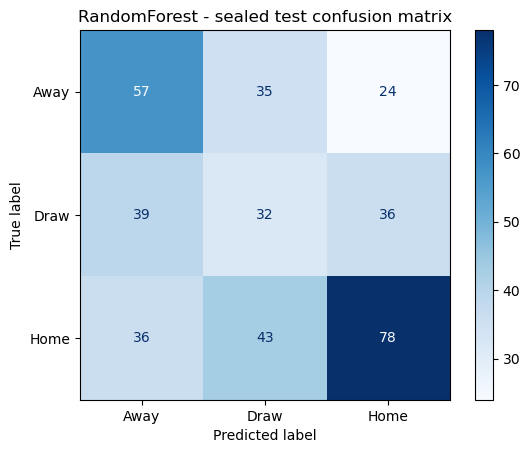

In [13]:
best  = final_models[FINAL_MODEL]
pred  = best.predict(X_test)
proba = best.predict_proba(X_test)

print(classification_report(y_test, pred, target_names=NAMES, zero_division=0))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=NAMES).plot(cmap='Blues')
plt.title(f'{FINAL_MODEL} - sealed test confusion matrix')
plt.show()

In [15]:
rng = np.random.default_rng(42)
y = y_test.values
proba_d, pred_d = dummy.predict_proba(X_test), dummy.predict(X_test)
n, B = len(y), 2000

boot = []
for _ in range(B):
    i = rng.integers(0, n, n)
    boot.append({'acc': accuracy_score(y[i], pred[i]),
                 'macro_f1': f1_score(y[i], pred[i], average='macro'),
                 'll_model': log_loss(y[i], proba[i], labels=LABELS),
                 'll_dummy': log_loss(y[i], proba_d[i], labels=LABELS),
                 'acc_dummy': accuracy_score(y[i], pred_d[i])})
boot = pd.DataFrame(boot)
boot['acc_gain'] = boot['acc'] - boot['acc_dummy']
boot['logloss_gain'] = boot['ll_dummy'] - boot['ll_model']     # positive = model is better

ci = boot.quantile([0.025, 0.5, 0.975]).T
ci.columns = ['2.5%', 'median', '97.5%']
display(ci.round(3))
print('Model beats always-Home accuracy in', round((boot['acc_gain'] > 0).mean() * 100, 1), '% of resamples')
print('Model beats prior log-loss in',        round((boot['logloss_gain'] > 0).mean() * 100, 1), '% of resamples')

,2.5%,median,97.5%
acc,0.389,0.439,0.489
macro_f1,0.377,0.426,0.477
ll_model,1.018,1.053,1.089
ll_dummy,1.061,1.089,1.117
acc_dummy,0.363,0.413,0.466
acc_gain,-0.042,0.026,0.092
logloss_gain,-0.007,0.035,0.078


Model beats always-Home accuracy in 75.2 % of resamples
Model beats prior log-loss in 95.4 % of resamples


In [17]:
ev = test[['date', 'home_team', 'away_team', 'FTR']].copy()
ev['pred'] = pd.Series(pred).map(dict(enumerate(NAMES))).values
ev['confidence'] = proba.max(axis=1)
ev['correct'] = (pred == y)

ev['conf_band'] = pd.qcut(ev['confidence'], 4, labels=['Q1 lowest', 'Q2', 'Q3', 'Q4 highest'])
display(ev.groupby('conf_band')['correct'].agg(['mean', 'count']).round(3))

ev['elo_gap'] = X_test['elo_diff'].abs().values
ev['gap_band'] = pd.qcut(ev['elo_gap'], 3, labels=['Evenly matched', 'Medium gap', 'Big mismatch'])
display(ev.groupby('gap_band')['correct'].agg(['mean', 'count']).round(3))

,mean,count
conf_band,,
Q1 lowest,0.326,95
Q2,0.347,95
Q3,0.442,95
Q4 highest,0.642,95


,mean,count
gap_band,,
Evenly matched,0.291,127
Medium gap,0.437,126
Big mismatch,0.591,127


,home_win,draw,away_win
season,,,
2008/2009,0.455,0.255,0.289
2009/2010,0.508,0.253,0.239
2010/2011,0.471,0.292,0.237
2011/2012,0.450,0.245,0.305
2012/2013,0.437,0.284,0.279
2013/2014,0.471,0.205,0.324
2014/2015,0.453,0.245,0.303
2015/2016,0.413,0.282,0.305


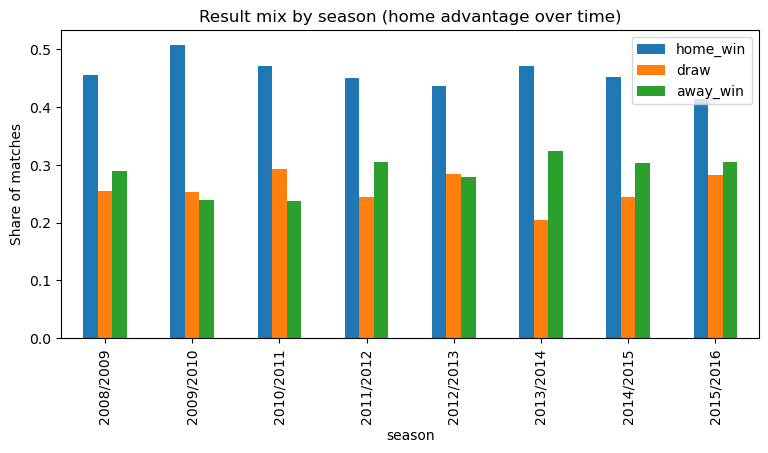

In [19]:
allm = all3.sort_values('date')
by_season = allm.groupby('season').agg(home_win=('FTR', lambda s: (s == 'H').mean()),
                                        draw=('FTR', lambda s: (s == 'D').mean()),
                                        away_win=('FTR', lambda s: (s == 'A').mean()))
display(by_season.round(3))
by_season.plot(kind='bar', figsize=(9, 4))
plt.title('Result mix by season (home advantage over time)')
plt.ylabel('Share of matches')
plt.show()

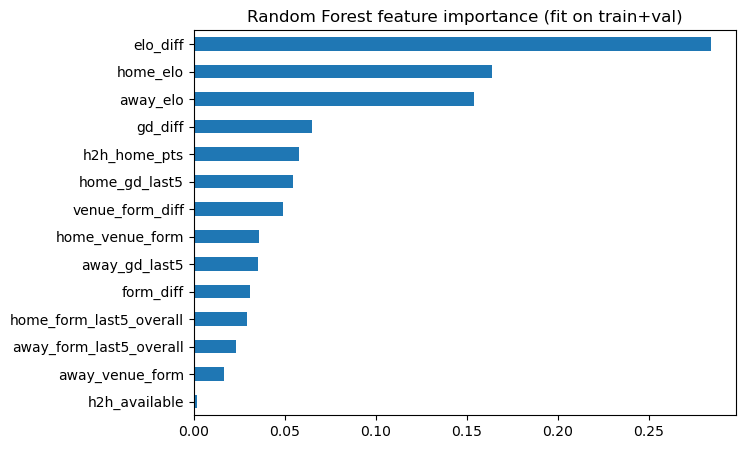

In [21]:
fi = pd.Series(best.named_steps['clf'].feature_importances_, index=features).sort_values()
fi.plot(kind='barh', figsize=(7, 5))
plt.title('Random Forest feature importance (fit on train+val)')
plt.show()

In [25]:
os.makedirs('../outputs', exist_ok=True)
test_res.to_csv('../outputs/test_results.csv', index=False)
ci.to_csv('../outputs/test_bootstrap_ci.csv')
ev.to_csv('../outputs/test_predictions.csv', index=False)
by_season.to_csv('../outputs/home_advantage_by_season.csv')
print('Saved')

Saved


| Decision | Options | Choice & evidence |
|---|---|---|
| Team-strength feature | Team_Attributes "style index" vs Elo rating | The style index (tactical settings, not player quality) had zero or negative permutation importance. Replaced with Elo (K=20, home advantage 60, start 1500, fixed in advance, not tuned). Val macro-F1 0.454 -> 0.487, log-loss 1.039 -> 0.995. Chosen using validation, so val scores are slightly optimistic. |
| Elo leakage control | Compute on all data vs sequentially | Rating used is the value BEFORE each match, updated AFTER. Part 3 never loaded test.csv. Part 4 asserts adding test leaves train/val ratings unchanged. |
| Reference model | Unbalanced LogReg | Declared before the test run, to show the accuracy/probability-quality vs draw-recall trade-off |

In [30]:
# A. Five real matches from the test season: probabilities vs what really happened
sample = test.sample(5, random_state=1)
proba = best.predict_proba(sample[features])
demo = sample[['date', 'home_team', 'away_team', 'FTR']].copy()
demo[['P_away', 'P_draw', 'P_home']] = proba.round(3)
demo['predicted'] = pd.Series(proba.argmax(axis=1), index=demo.index).map(dict(enumerate(NAMES)))
display(demo)

# B. What-if: invent a match by choosing the Elo ratings (other clues start at the training average)
def what_if(home_elo=1500, away_elo=1500, **overrides):
    row = X_tv.mean().to_frame().T.copy()
    row['home_elo'], row['away_elo'] = home_elo, away_elo
    row['elo_diff'] = home_elo - away_elo
    for k, v in overrides.items():
        row[k] = v
    row['form_diff'] = row['home_form_last5_overall'] - row['away_form_last5_overall']
    row['gd_diff'] = row['home_gd_last5'] - row['away_gd_last5']
    row['venue_form_diff'] = row['home_venue_form'] - row['away_venue_form']
    p = best.predict_proba(row[features])[0]
    return dict(zip(NAMES, p.round(3)))

print('Big home favourite:', what_if(1650, 1450))
print('Evenly matched:    ', what_if(1520, 1520))
print('Away much stronger:', what_if(1450, 1650))
print('Hot home form:     ', what_if(1550, 1500, home_form_last5_overall=2.6, home_gd_last5=1.5))

,date,home_team,away_team,FTR,P_away,P_draw,P_home,predicted
244,2016-02-06,Manchester City,Leicester City,A,0.256,0.264,0.480,Home
180,2015-12-28,West Ham United,Southampton,H,0.339,0.381,0.280,Draw
277,2016-03-02,Stoke City,Newcastle United,H,0.210,0.372,0.418,Home
185,2015-12-28,Norwich City,Aston Villa,H,0.291,0.385,0.324,Draw
233,2016-02-02,Crystal Palace,Bournemouth,A,0.304,0.390,0.306,Draw


Big home favourite: {'Away': 0.166, 'Draw': 0.262, 'Home': 0.572}
Evenly matched:     {'Away': 0.301, 'Draw': 0.382, 'Home': 0.317}
Away much stronger: {'Away': 0.485, 'Draw': 0.329, 'Home': 0.186}
Hot home form:      {'Away': 0.247, 'Draw': 0.329, 'Home': 0.425}
